In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os

project_path = '/content/drive/MyDrive/cnn_project'
os.makedirs(project_path, exist_ok=True)

In [4]:
import os
os.environ['KERAS_HOME'] = '/content/drive/MyDrive/keras_cache'

In [5]:
# Create folder structure
os.makedirs(f'{project_path}/notebooks', exist_ok=True)
os.makedirs(f'{project_path}/checkpoints/cnn1', exist_ok=True)
os.makedirs(f'{project_path}/checkpoints/cnn2', exist_ok=True)
os.makedirs(f'{project_path}/models', exist_ok=True)

In [6]:
import tensorflow as tf

In [7]:
import tensorflow.keras
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Input, Flatten, Rescaling, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import RMSprop, Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [8]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [9]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
X_train.shape

(50000, 32, 32, 3)

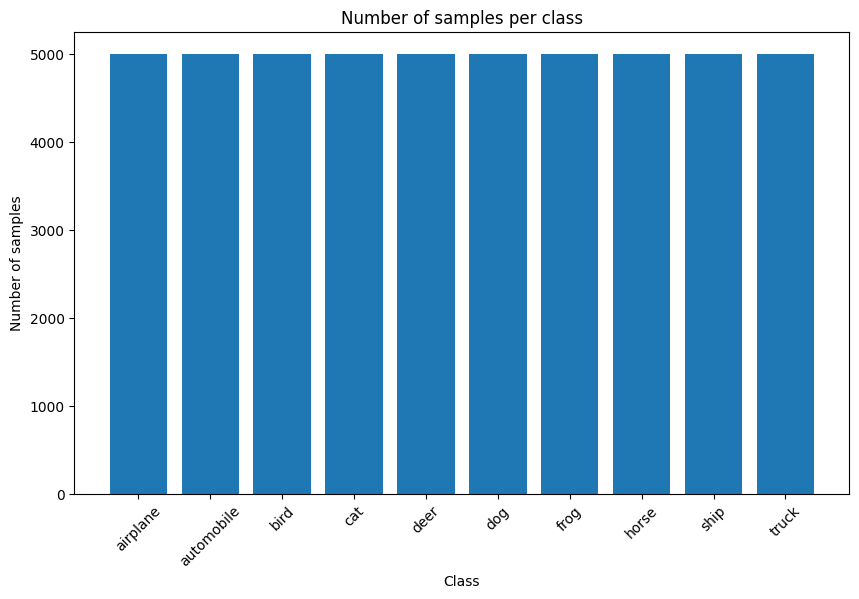

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


In [ ]:
# Check the training set balance
from collections import Counter


labels = y_train

# Count the number of samples per class
class_counts = Counter(labels.flatten())

# Sort by class index
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]


# Plotting
plt.figure(figsize=(10, 6))
plt.bar(class_names, counts)
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Number of samples per class')
plt.xticks(rotation=45)
plt.show()

# Optional: print counts for reference
for cls, count in zip(class_names, counts):
    print(f"{cls}: {count}")


The training dataset is balanced.

In [11]:
# Convert labels to one-hot vectors
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [12]:
# Rescalling data
normalization_layer = Rescaling(1./255)
X_train_norm = normalization_layer(X_train)
X_test_norm = normalization_layer(X_test)

print(X_train_norm.shape[0], 'train samples')
print(X_test_norm.shape[0], 'test samples')

50000 train samples
10000 test samples


In [ ]:
print(X_train_norm)

tf.Tensor(
[[[[0.23137257 0.24313727 0.24705884]
   [0.16862746 0.18039216 0.1764706 ]
   [0.19607845 0.18823531 0.16862746]
   ...
   [0.61960787 0.5176471  0.42352945]
   [0.59607846 0.4901961  0.40000004]
   [0.5803922  0.48627454 0.4039216 ]]

  [[0.0627451  0.07843138 0.07843138]
   [0.         0.         0.        ]
   [0.07058824 0.03137255 0.        ]
   ...
   [0.48235297 0.34509805 0.21568629]
   [0.4666667  0.3254902  0.19607845]
   [0.4784314  0.34117648 0.22352943]]

  [[0.09803922 0.09411766 0.08235294]
   [0.0627451  0.02745098 0.        ]
   [0.19215688 0.10588236 0.03137255]
   ...
   [0.46274513 0.32941177 0.19607845]
   [0.47058827 0.32941177 0.19607845]
   [0.427451   0.28627452 0.16470589]]

  ...

  [[0.81568635 0.6666667  0.37647063]
   [0.78823537 0.6        0.13333334]
   [0.77647066 0.6313726  0.10196079]
   ...
   [0.627451   0.52156866 0.27450982]
   [0.21960786 0.12156864 0.02745098]
   [0.20784315 0.13333334 0.07843138]]

  [[0.7058824  0.54509807 0.376470

In [ ]:
##### Build the model

model = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    MaxPooling2D(2,2),
                    Conv2D(64, (3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Flatten(),
                    Dense(128, activation='relu'),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:


project_path = '/content/drive/MyDrive/cnn_project'

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history = model.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1243/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3738 - loss: 1.7171
Epoch 1: val_accuracy improved from None to 0.57090, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4649 - loss: 1.4842 - val_accuracy: 0.5709 - val_loss: 1.2137
Epoch 2/50
1240/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5953 - loss: 1.1400
Epoch 2: val_accuracy improved from 0.57090 to 0.61900, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6096 - loss: 1.1060 - val_accuracy: 0.6190 - val_loss: 1.0846
Epoch 3/50
1236/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6633 - loss: 0.9650
Epoch 3: v

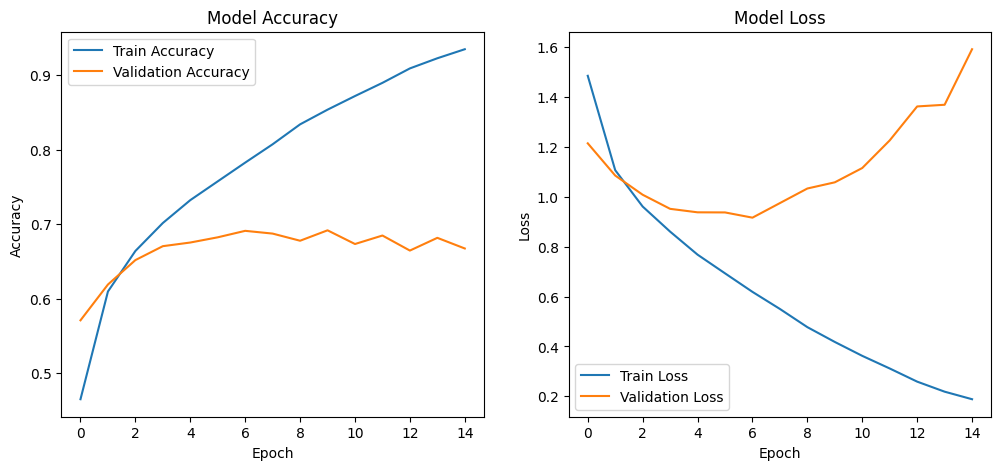

In [ ]:
import matplotlib.pylab as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
model.save(f'{project_path}/models/cnn1_final.keras')

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model(f'{project_path}/models/cnn1_final.keras')

In [ ]:
score = best_model.evaluate(X_test_norm, y_test_cat, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 1.081868290901184
Test accuracy: 0.6883000135421753


In [ ]:
model_2 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Dropout(0.2),
                    Flatten(),
                    Dense(512, activation='relu'),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_2.summary()
model_2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,670,858 (14.00 MB)

 Trainable params: 3,670,858 (14.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

project_path = '/content/drive/MyDrive/cnn_project'

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_2.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history = model_2.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1247/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3827 - loss: 1.6535
Epoch 1: val_accuracy improved from None to 0.62940, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_2.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.4886 - loss: 1.3972 - val_accuracy: 0.6294 - val_loss: 1.0579
Epoch 2/50
1242/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6484 - loss: 0.9917
Epoch 2: val_accuracy improved from 0.62940 to 0.71210, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_2.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6651 - loss: 0.9454 - val_accuracy: 0.7121 - val_loss: 0.8181
Epoch 3/50
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7329 - loss: 0.7530
Ep

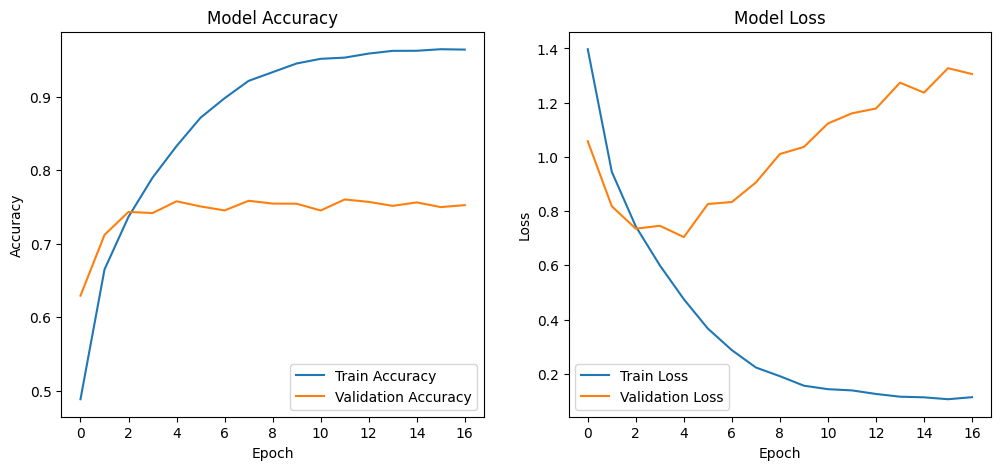

In [ ]:
import matplotlib.pylab as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
# Replace Flatten and Dense layers with GlobalAveragePooling
model_3 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Dropout(0.2),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_3.summary()
model_3.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,986 (1.49 MB)

 Trainable params: 390,986 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

project_path = '/content/drive/MyDrive/cnn_project'

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_3.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history = model_3.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1249/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2948 - loss: 1.8324
Epoch 1: val_accuracy improved from None to 0.51220, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_3.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.3831 - loss: 1.6340 - val_accuracy: 0.5122 - val_loss: 1.3651
Epoch 2/50
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5293 - loss: 1.3164
Epoch 2: val_accuracy improved from 0.51220 to 0.59830, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_3.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_3.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5548 - loss: 1.2473 - val_accuracy: 0.5983 - val_loss: 1.1357
Epoch 3/50
1247/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6142 - loss: 1.0921
Ep

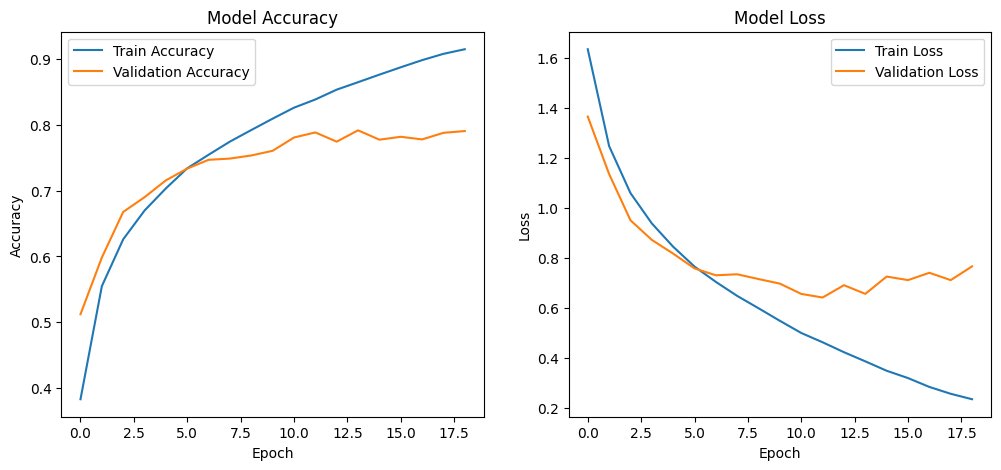

In [ ]:
import matplotlib.pylab as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Increase dropout to 0.5
model_4 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                    MaxPooling2D(2,2),
                    Dropout(0.5),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_4.summary()
model_4.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 390,986 (1.49 MB)

 Trainable params: 390,986 (1.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

project_path = '/content/drive/MyDrive/cnn_project'

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_4.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_accuracy',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_4 = model_4.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2812 - loss: 1.8848
Epoch 1: val_accuracy improved from None to 0.49330, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_4.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_4.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.3717 - loss: 1.6718 - val_accuracy: 0.4933 - val_loss: 1.4069
Epoch 2/50
1245/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5096 - loss: 1.3558
Epoch 2: val_accuracy improved from 0.49330 to 0.57280, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_4.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_4.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5318 - loss: 1.3023 - val_accuracy: 0.5728 - val_loss: 1.1785
Epoch 3/50
1247/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5886 - loss: 1.1621
Ep

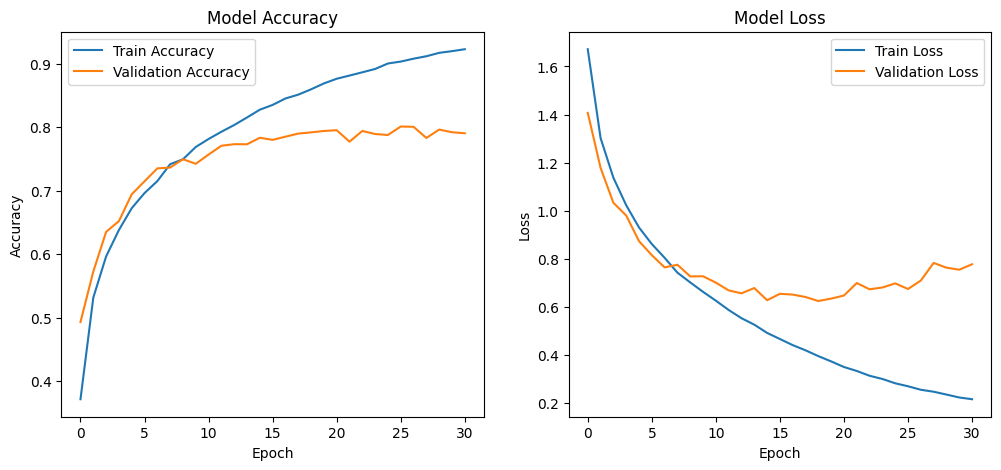

In [ ]:
import matplotlib.pylab as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_4.history['accuracy'], label='Train Accuracy')
plt.plot(history_4.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_4.history['loss'], label='Train Loss')
plt.plot(history_4.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
# Add batch normalization
model_5 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Dropout(0.5),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_5.summary()
model_5.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,266 (1.50 MB)

 Trainable params: 391,626 (1.49 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
#change monitor to 'val_loss'
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_5.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_5 = model_5.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1247/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4214 - loss: 1.6067
Epoch 1: val_loss improved from None to 1.50902, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_5.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_5.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.5027 - loss: 1.3850 - val_accuracy: 0.5066 - val_loss: 1.5090
Epoch 2/50
1242/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6402 - loss: 1.0212
Epoch 2: val_loss improved from 1.50902 to 0.97879, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_5.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_5.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6571 - loss: 0.9816 - val_accuracy: 0.6552 - val_loss: 0.9788
Epoch 3/50
1243/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7082 - loss: 0.8423
Epoch 3: v

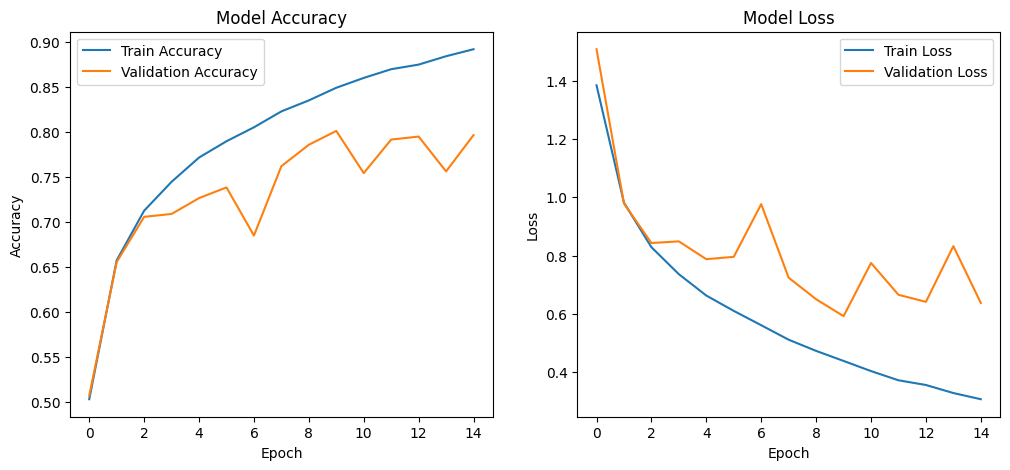

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_5.history['accuracy'], label='Train Accuracy')
plt.plot(history_5.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_5.history['loss'], label='Train Loss')
plt.plot(history_5.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

The overfitting was reduced, but the training and validation loss are still high.

In [ ]:
# Decrease the learning rate to 1e-5
model_6 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Dropout(0.5),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Reduce learning rate
model_6.summary()
model_6.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,266 (1.50 MB)

 Trainable params: 391,626 (1.49 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_6.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_6 = model_6.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2714 - loss: 2.0223
Epoch 1: val_loss improved from None to 1.58906, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_6.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_6.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.3329 - loss: 1.8347 - val_accuracy: 0.4290 - val_loss: 1.5891
Epoch 2/50
1244/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4233 - loss: 1.6038
Epoch 2: val_loss improved from 1.58906 to 1.45713, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_6.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_6.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.4350 - loss: 1.5698 - val_accuracy: 0.4799 - val_loss: 1.4571
Epoch 3/50
1244/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4682 - loss: 1.4836
Epoch 3: 

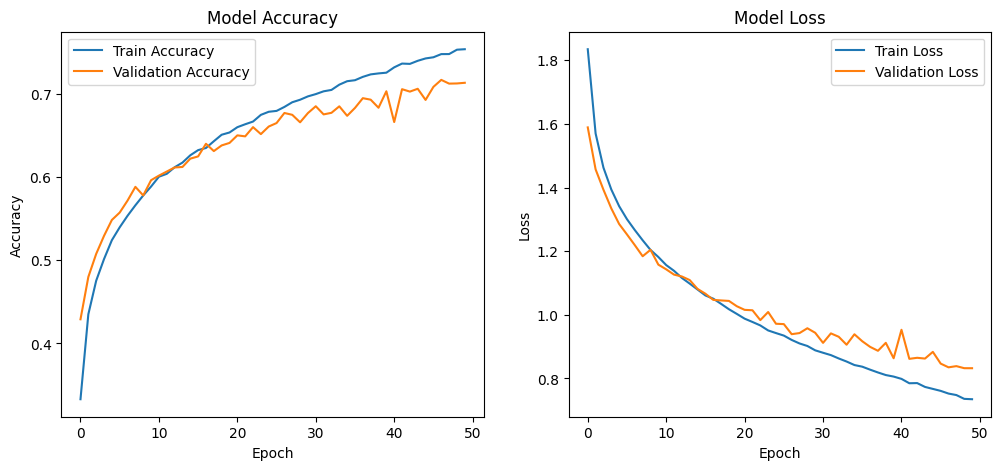

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_6.history['accuracy'], label='Train Accuracy')
plt.plot(history_6.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_6.history['loss'], label='Train Loss')
plt.plot(history_6.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

The reduction of the learning rate employed on model 6 did not improve the model's performance.
For the next test, l2 regularization will be performed on model 5.

In [ ]:
# Add L2 regularization
model_7 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3),kernel_regularizer=l2(1e-4)),
                    Conv2D(64,(3,3), activation='relu', kernel_regularizer=l2(1e-4)),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu', kernel_regularizer=l2(1e-4)),
                    Conv2D(256, (3,3), activation='relu', kernel_regularizer=l2(1e-4)),
                    MaxPooling2D(2,2),
                    Dropout(0.5),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_7.summary()
model_7.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,242 (1.49 MB)

 Trainable params: 391,114 (1.49 MB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_7.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_7 = model_7.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1243/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3913 - loss: 1.6762
Epoch 1: val_loss improved from None to 1.45425, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_7.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_7.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.4846 - loss: 1.4548 - val_accuracy: 0.5125 - val_loss: 1.4543
Epoch 2/50
1242/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6293 - loss: 1.1210
Epoch 2: val_loss improved from 1.45425 to 1.06847, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_7.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_7.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6453 - loss: 1.0711 - val_accuracy: 0.6426 - val_loss: 1.0685
Epoch 3/50
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6932 - loss: 0.9539
Epoch 3: v

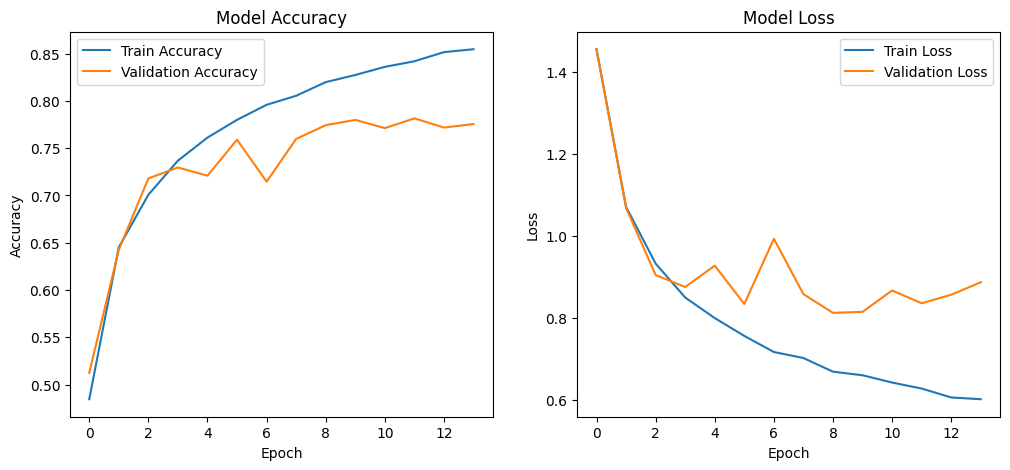

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_7.history['accuracy'], label='Train Accuracy')
plt.plot(history_7.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_7.history['loss'], label='Train Loss')
plt.plot(history_7.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

When compared with model 5, the L2 regularization did not improve the model's performance.

In [ ]:
# Add batch normalization
model_5 = Sequential([Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
                    Conv2D(64,(3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Conv2D(128, (3,3), activation='relu'),
                    Conv2D(256, (3,3), activation='relu'),
                      BatchNormalization(),
                    MaxPooling2D(2,2),
                    Dropout(0.5),
                    GlobalAveragePooling2D(),
                    Dense(10, activation='softmax')
                    ])

Model 8 Has padding and Normalisation after each Conv step / Dense changed from Model 5 / we have two dropouts .2 and  .3 instead of .5

In [ ]:

model_8 = Sequential([

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    Conv2D(
        256,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.3),

    GlobalAveragePooling2D(),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_8.summary()
model_8.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,906 (1.50 MB)

 Trainable params: 391,946 (1.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_8.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

history_8 = model_8.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping])

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9201 - loss: 0.2281
Epoch 1: val_loss improved from None to 0.62437, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_8.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_8.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.9147 - loss: 0.2436 - val_accuracy: 0.8209 - val_loss: 0.6244
Epoch 2/50
1248/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9262 - loss: 0.2136
Epoch 2: val_loss improved from 0.62437 to 0.58604, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_8.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_8.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.9197 - loss: 0.2294 - val_accuracy: 0.8246 - val_loss: 0.5860
Epoch 3/50
1246/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9297 - loss: 0.1994
Epoch 3:

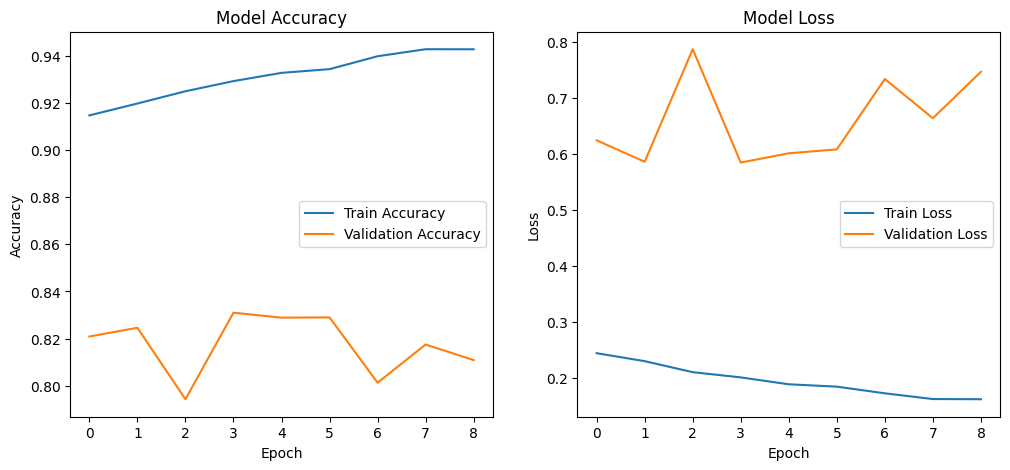

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_8.history['accuracy'], label='Train Accuracy')
plt.plot(history_8.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_8.history['loss'], label='Train Loss')
plt.plot(history_8.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:

model_9 = Sequential([

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    Conv2D(
        256,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.3),

    GlobalAveragePooling2D(),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_9.summary()
model_9.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,906 (1.50 MB)

 Trainable params: 391,946 (1.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_9.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_LR = ReduceLROnPlateau(
           monitor='val_loss',
            factor=0.5,
            patience=2
)

history_9 = model_9.fit(X_train_norm, y_train_cat,
          validation_data=(X_test_norm, y_test_cat),
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping,reduce_LR])

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4784 - loss: 1.4739
Epoch 1: val_loss improved from None to 1.10695, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_9.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_9.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 13ms/step - accuracy: 0.5590 - loss: 1.2396 - val_accuracy: 0.6040 - val_loss: 1.1070 - learning_rate: 0.0010
Epoch 2/50
1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6841 - loss: 0.9062
Epoch 2: val_loss improved from 1.10695 to 1.09117, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_9.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_9.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6963 - loss: 0.8706 - val_accuracy: 0.6341 - val_loss: 1.0912 - learning_rate: 0.0010
Epoch 3/50
1560/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 8

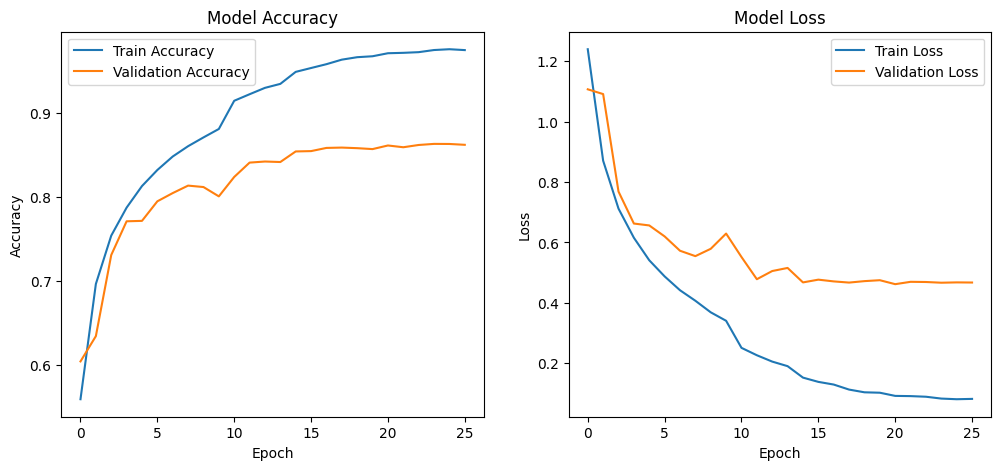

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_9.history['accuracy'], label='Train Accuracy')
plt.plot(history_9.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_9.history['loss'], label='Train Loss')
plt.plot(history_9.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [12]:
model_10 = Sequential([

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    Conv2D(
        256,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.3),

    GlobalAveragePooling2D(),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model_10.summary()
model_10.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,906 (1.50 MB)

 Trainable params: 391,946 (1.50 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_10.keras',
    save_best_only=True,  # only saves if model improved
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,        # stops if no improvement for 5 epochs
    restore_best_weights=True,  # rolls back to best weights when stopping
    verbose=1
)

reduce_LR = ReduceLROnPlateau(
           monitor='val_loss',
            factor=0.5,
            patience=2
)


history_10 = model_10.fit(X_train_norm, y_train_cat,
          validation_split=0.2, # Keras takes the last 20% of X_train automatically
          epochs=50, # set high — early stopping will interrupt,
          batch_size=32,
          callbacks=[checkpoint, early_stopping, reduce_LR])

Epoch 1/50
1244/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3869 - loss: 1.7701
Epoch 1: val_loss improved from None to 1.67852, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.4763 - loss: 1.4641 - val_accuracy: 0.4116 - val_loss: 1.6785 - learning_rate: 0.0010
Epoch 2/50
1244/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6019 - loss: 1.1164
Epoch 2: val_loss improved from 1.67852 to 0.95879, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10.keras
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6231 - loss: 1.0686 - val_accuracy: 0.6580 - val_loss: 0.9588 - learning_rate: 0.0010
Epoch 3/50
1240/1250 ━━━━━━━━━━━━━━━━━━━━ 0s 3

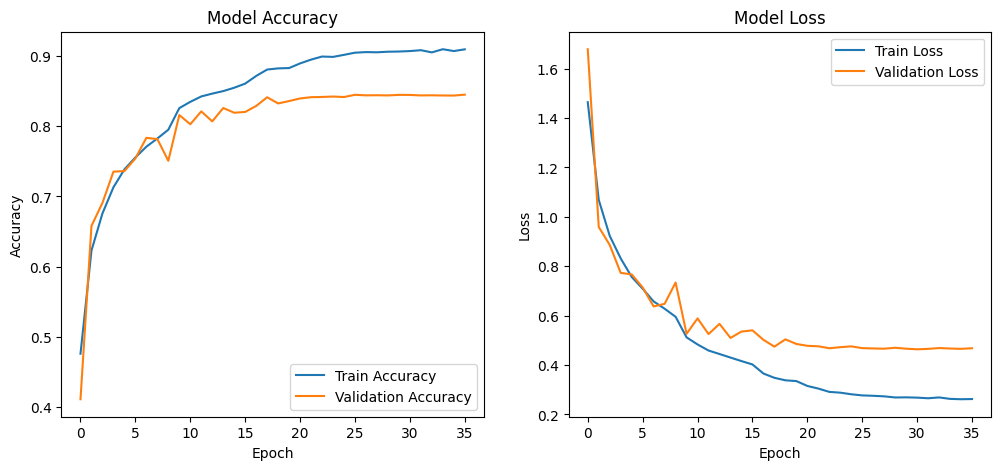

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_10.history['accuracy'], label='Train Accuracy')
plt.plot(history_10.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_10.history['loss'], label='Train Loss')
plt.plot(history_10.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [16]:
# Setup data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train_norm)

# Callbacks
checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/best_model_10_Jan.keras',
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

# Train model
history_10_Jan = model_10.fit(
    datagen.flow(
        X_train_norm,
        y_train_cat,
        batch_size=64
    ),

    validation_data=(
        X_test_norm,
        y_test_cat
    ),

    epochs=50,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/50
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7794 - loss: 0.6855
Epoch 1: val_loss improved from None to 0.58686, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10_Jan.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/best_model_10_Jan.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.7788 - loss: 0.6875 - val_accuracy: 0.8267 - val_loss: 0.5869 - learning_rate: 3.9063e-06
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7752 - loss: 0.6969
Epoch 2: val_loss did not improve from 0.58686
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7779 - loss: 0.6868 - val_accuracy: 0.8237 - val_loss: 0.6053 - learning_rate: 3.9063e-06
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7851 - loss: 0.6747
Epoch 3: val_loss did not improve from 0.58686

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
782/782 ━━━━━━━━━━━━━

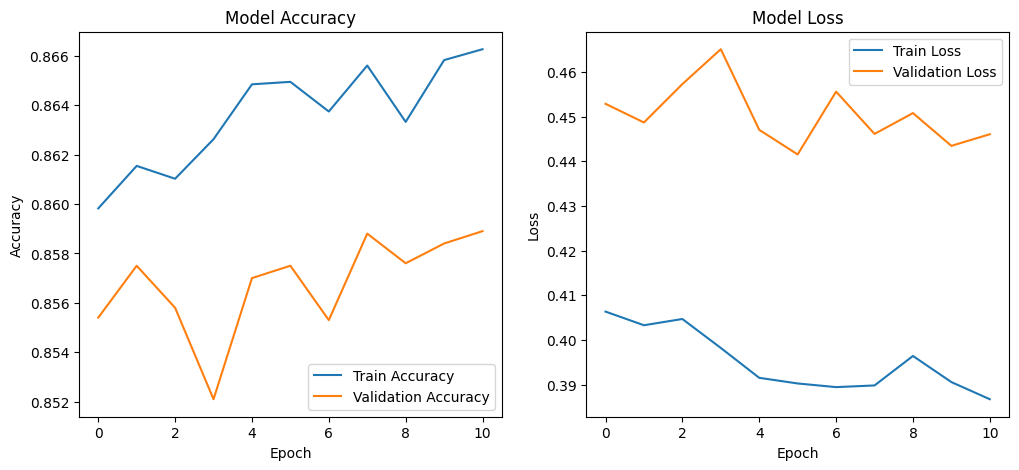

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_10_Jan.history['accuracy'], label='Train Accuracy')
plt.plot(history_10_Jan.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_10_Jan.history['loss'], label='Train Loss')
plt.plot(history_10_Jan.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
model_10.save(f"{project_path}/models/model_10_final.keras")

In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Resizing,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

# Load pretrained DenseNet
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Build transfer learning model
model_densenet = Sequential([

    Input(shape=(32, 32, 3)),
    Conv2D()
    Resizing(224, 224),

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(10, activation='softmax')
])

In [ ]:
from tensorflow.keras.optimizers import Adam

model_densenet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_densenet = model_densenet.fit(
    datagen.flow(
        X_train_norm,
        y_train_cat,
        batch_size=64
    ),

    validation_data=(
        X_test_norm,
        y_test_cat
    ),

    epochs=20,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/20


KeyboardInterrupt: 

In [ ]:
filepath=f'{project_path}/checkpoints/cnn1/densenet_best.keras'

##Full Version

In [18]:
from tensorflow.keras.models import load_model, Model

# Load trained CNN
model_10 = load_model(
    f"{project_path}/models/model_10_final.keras"
)

# Build model explicitly
model_10.build((None, 32, 32, 3))

# Check architecture
model_10.summary()

# Remove classification head
base_model = Model(
    inputs=model_10.input,
    outputs=model_10.layers[-2].output
)

base_model.trainable = False

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,176,800 (4.49 MB)

 Trainable params: 391,946 (1.50 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 783,894 (2.99 MB)

AttributeError: The layer sequential has never been called and thus has no defined input.

In [17]:
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# =========================================================
# 1. LOAD EXISTING CNN MODEL (MODEL_10)
# =========================================================

model_10 = load_model(
    f"{project_path}/models/model_10_final.keras"
)

# Inspect architecture
model_10.summary()

# =========================================================
# 2. REMOVE OLD CLASSIFICATION HEAD
# =========================================================
# We take everything except the final softmax layer

base_model = Model(
    inputs=model_10.input,
    outputs=model_10.layers[-2].output
)

# Freeze pretrained CNN layers initially
base_model.trainable = False

# =========================================================
# 3. BUILD IMPROVED TRANSFER LEARNING MODEL
# =========================================================

from tensorflow.keras.models import Sequential

model_densenet_tuned = Sequential([

    Input(shape=(32, 32, 3)),

    # Existing pretrained CNN backbone
    base_model,

    # Additional regularization / feature learning
    BatchNormalization(),

    Dropout(0.4),

    Dense(256, activation='relu'),

    Dropout(0.3),

    Dense(10, activation='softmax')

])

# =========================================================
# 4. COMPILE MODEL
# =========================================================

model_densenet_tuned.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# 5. CALLBACKS
# =========================================================

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/model10_transfer_best.keras',
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

# =========================================================
# 6. TRAIN HEAD ONLY
# =========================================================

history_transfer = model_densenet_tuned.fit(

    datagen.flow(
        X_train_norm,
        y_train_cat,
        batch_size=64
    ),

    validation_data=(
        X_test_norm,
        y_test_cat
    ),

    epochs=20,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

# =========================================================
# 7. OPTIONAL: UNFREEZE LAST LAYERS FOR FINE-TUNING
# =========================================================

base_model.trainable = True

# Freeze most layers, train only deeper layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Lower LR for fine-tuning
model_densenet_tuned.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# 8. FINE-TUNE
# =========================================================

history_finetune = model_densenet_tuned.fit(

    datagen.flow(
        X_train_norm,
        y_train_cat,
        batch_size=64
    ),

    validation_data=(
        X_test_norm,
        y_test_cat
    ),

    epochs=10,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

# =========================================================
# 9. SAVE FINAL MODEL
# =========================================================

model_densenet_tuned.save(
    f"{project_path}/models/model10_transfer_final.keras"
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,176,800 (4.49 MB)

 Trainable params: 391,946 (1.50 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 783,894 (2.99 MB)

AttributeError: The layer sequential has never been called and thus has no defined input.

In [ ]:
# Callbacks for DenseNet

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/densenet_best.keras',
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

# Train DenseNet
history_densenet = model_densenet.fit(

    datagen.flow(
        X_train_norm,
        y_train_cat,
        batch_size=64
    ),

    validation_data=(
        X_test_norm,
        y_test_cat
    ),

    epochs=20,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4856 - loss: 1.4885
Epoch 1: val_loss improved from None to 0.67755, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 115s 147ms/step - accuracy: 0.5907 - loss: 1.1940 - val_accuracy: 0.7766 - val_loss: 0.6775 - learning_rate: 0.0010
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6742 - loss: 0.9482
Epoch 2: val_loss improved from 0.67755 to 0.63502, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.6779 - loss: 0.9368 - val_accuracy: 0.7850 - val_loss: 0.6350 - learning_rate: 0.0010
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms

In [ ]:
# Unfreeze DenseNet
base_model.trainable = True

# Freeze earlier layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

In [ ]:
from tensorflow.keras.optimizers import Adam

model_densenet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_finetune = model_densenet.fit(

    datagen.flow(
        X_train_norm,
        y_train_cat,
        batch_size=64
    ),

    validation_data=(
        X_test_norm,
        y_test_cat
    ),

    epochs=10,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.5985 - loss: 1.7790
Epoch 1: val_loss did not improve from 0.56681
782/782 ━━━━━━━━━━━━━━━━━━━━ 153s 145ms/step - accuracy: 0.6354 - loss: 1.4875 - val_accuracy: 0.8005 - val_loss: 0.7187 - learning_rate: 1.0000e-05
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6810 - loss: 1.1743
Epoch 2: val_loss did not improve from 0.56681

Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 89ms/step - accuracy: 0.6844 - loss: 1.1617 - val_accuracy: 0.8142 - val_loss: 0.6518 - learning_rate: 1.0000e-05
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6957 - loss: 1.0911
Epoch 3: val_loss did not improve from 0.56681
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 89ms/step - accuracy: 0.6950 - loss: 1.0909 - val_accuracy: 0.8183 - val_loss: 0.6342 - learning_rate: 5.0000e-06
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6953 - los

In [ ]:
from tensorflow.keras.applications.densenet import preprocess_input

In [ ]:
model_densenet.save(
    f"{project_path}/models/densenet_final.keras"
)

#last attempt

In [19]:
# =========================================================
# IMPORTS
# =========================================================

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Dropout,
    GlobalAveragePooling2D,
    Dense
)

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

# =========================================================
# 1. ORIGINAL CNN MODEL (MODEL_10)
# =========================================================

model_10 = Sequential([

    Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(
        128,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    Conv2D(
        256,
        (3,3),
        padding='same',
        activation='relu'
    ),
    BatchNormalization(),

    MaxPooling2D(2,2),
    Dropout(0.3),

    GlobalAveragePooling2D(),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# =========================================================
# 2. COMPILE ORIGINAL MODEL
# =========================================================

model_10.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# 3. TRAIN ORIGINAL CNN
# =========================================================

history_model10 = model_10.fit(

    datagen.flow(
        X_train_norm,
        y_train_cat,
        batch_size=64
    ),

    validation_data=(
        X_test_norm,
        y_test_cat
    ),

    epochs=20
)

# =========================================================
# 4. SAVE ORIGINAL MODEL
# =========================================================

model_10.save(
    f"{project_path}/models/model_10_final.keras"
)

# =========================================================
# 5. CREATE TRANSFER LEARNING BACKBONE
# =========================================================
# Remove final softmax classifier

base_model = Model(
    inputs=model_10.inputs,
    outputs=model_10.layers[-2].output
)

# Freeze pretrained CNN layers
base_model.trainable = False

# =========================================================
# 6. BUILD IMPROVED TRANSFER MODEL
# =========================================================

transfer_model = Sequential([

    base_model,

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

# =========================================================
# 7. COMPILE TRANSFER MODEL
# =========================================================

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# 8. CALLBACKS
# =========================================================

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/model10_transfer_best.keras',
    save_best_only=True,
    monitor='val_loss',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

# =========================================================
# 9. TRAIN TRANSFER MODEL
# =========================================================

history_transfer = transfer_model.fit(

    datagen.flow(
        X_train_norm,
        y_train_cat,
        batch_size=64
    ),

    validation_data=(
        X_test_norm,
        y_test_cat
    ),

    epochs=20,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

# =========================================================
# 10. OPTIONAL FINE-TUNING
# =========================================================
# Unfreeze deeper layers

base_model.trainable = True

# Freeze earlier layers
for layer in base_model.layers[:-8]:
    layer.trainable = False

# Recompile with smaller LR
transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune
history_finetune = transfer_model.fit(

    datagen.flow(
        X_train_norm,
        y_train_cat,
        batch_size=64
    ),

    validation_data=(
        X_test_norm,
        y_test_cat
    ),

    epochs=10,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

# =========================================================
# 11. SAVE FINAL TRANSFER MODEL
# =========================================================

transfer_model.save(
    f"{project_path}/models/model10_transfer_final.keras"
)

# =========================================================
# 12. EVALUATE
# =========================================================

test_loss, test_accuracy = transfer_model.evaluate(
    X_test_norm,
    y_test_cat
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.4400 - loss: 1.5687 - val_accuracy: 0.5379 - val_loss: 1.2536
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.5831 - loss: 1.1751 - val_accuracy: 0.5217 - val_loss: 1.4558
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6440 - loss: 1.0205 - val_accuracy: 0.4974 - val_loss: 1.5346
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6765 - loss: 0.9249 - val_accuracy: 0.7152 - val_loss: 0.8341
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.7023 - loss: 0.8613 - val_accuracy: 0.5887 - val_loss: 1.3670
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.7183 - loss: 0.8110 - val_accuracy: 0.7043 - val_loss: 0.9430
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7315 - loss: 0.7846 - val_accuracy: 0.7050 - val_loss: 0.8683
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.7377 - loss: 0.7560 - 

In [24]:
# =========================================================
# IMPORTS
# =========================================================

import tensorflow as tf

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Resizing,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast
)

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

# =========================================================
# 1. LOAD PRETRAINED DENSENET
# =========================================================

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# =========================================================
# 2. FREEZE MOST LAYERS
# =========================================================
# Fine-tune only deeper layers

base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

# =========================================================
# 3. BUILD IMPROVED MODEL
# =========================================================

model_densenet = Sequential([

    # CIFAR-10 input
    Input(shape=(32,32,3)),


    # Resize for DenseNet
    Resizing(224,224),

    # DenseNet preprocessing
    tf.keras.layers.Lambda(preprocess_input),

    # Backbone
    base_model,

    # Pooling
    GlobalAveragePooling2D(),

    # Better stabilization
    BatchNormalization(),

    # Lower dropout
    Dropout(0.25),

    # Additional feature layer
    Dense(
        64,
        activation='relu'
    ),

    BatchNormalization(),

    Dropout(0.2),

    # Final classifier
    Dense(
        10,
        activation='softmax'
    )
])

# =========================================================
# 4. COMPILE
# =========================================================

model_densenet.compile(

    optimizer=Adam(
        learning_rate=1e-2
    ),

    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=['accuracy']
)

# =========================================================
# 5. CALLBACKS
# =========================================================

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/densenet_best.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# =========================================================
# 6. TRAIN
# =========================================================

history_densenet = model_densenet.fit(

    datagen.flow(
        X_train_norm,
        y_train_cat,
        batch_size=64
    ),

    validation_data=(
        X_test_norm,
        y_test_cat
    ),

    epochs=30,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

# =========================================================
# 7. SAVE MODEL
# =========================================================

model_densenet.save(
    f"{project_path}/models/densenet_optimized_final.keras"
)

# =========================================================
# 8. EVALUATE
# =========================================================

test_loss, test_accuracy = model_densenet.evaluate(
    X_test_norm,
    y_test_cat
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.3886 - loss: 1.8625
Epoch 1: val_accuracy improved from None to 0.11390, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 159s 158ms/step - accuracy: 0.4348 - loss: 1.7422 - val_accuracy: 0.1139 - val_loss: 11.7773 - learning_rate: 0.0100
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.4848 - loss: 1.6327
Epoch 2: val_accuracy improved from 0.11390 to 0.14490, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 89ms/step - accuracy: 0.4915 - loss: 1.6213 - val_accuracy: 0.1449 - val_loss: 9.1270 - learning_rate: 0.0100
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━

In [25]:
# =========================================================
# DENSENET121 TRANSFER LEARNING WITH AUTOTUNE
# =========================================================

import tensorflow as tf

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization,
    Resizing
)

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

# =========================================================
# AUTOTUNE
# =========================================================

AUTOTUNE = tf.data.AUTOTUNE

# =========================================================
# 1. LOAD PRETRAINED DENSENET
# =========================================================

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# =========================================================
# 2. PARTIAL FINE-TUNING
# =========================================================

base_model.trainable = True

for layer in base_model.layers[:-25]:
    layer.trainable = False

# =========================================================
# 3. BUILD MODEL
# =========================================================

inputs = Input(shape=(32,32,3))

# Resize CIFAR images
x = Resizing(224,224)(inputs)

# Correct DenseNet preprocessing
x = preprocess_input(x)

# DenseNet backbone
x = base_model(x, training=False)

# Classification head
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = Dropout(0.3)(x)

outputs = Dense(
    10,
    activation='softmax'
)(x)

# Final model
model_densenet = Model(
    inputs,
    outputs
)

# =========================================================
# 4. COMPILE
# =========================================================

model_densenet.compile(

    optimizer=Adam(
        learning_rate=1e-4
    ),

    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=['accuracy']
)

# =========================================================
# 5. TF.DATA PIPELINE WITH AUTOTUNE
# =========================================================

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train_cat)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test_cat)
)

# Shuffle + batch
train_ds = train_ds.shuffle(5000)

train_ds = train_ds.batch(64)

test_ds = test_ds.batch(64)

# Prefetch for performance
train_ds = train_ds.prefetch(AUTOTUNE)

test_ds = test_ds.prefetch(AUTOTUNE)

# =========================================================
# 6. CALLBACKS
# =========================================================

checkpoint = ModelCheckpoint(
    filepath=f'{project_path}/checkpoints/cnn1/densenet_best.keras',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# =========================================================
# 7. TRAIN
# =========================================================

history_densenet = model_densenet.fit(

    train_ds,

    validation_data=test_ds,

    epochs=20,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

# =========================================================
# 8. FINE-TUNING STAGE
# =========================================================

base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

# Recompile with lower LR
model_densenet.compile(

    optimizer=Adam(
        learning_rate=1e-5
    ),

    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),

    metrics=['accuracy']
)

# Fine-tune
history_finetune = model_densenet.fit(

    train_ds,

    validation_data=test_ds,

    epochs=10,

    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ]
)

# =========================================================
# 9. SAVE MODEL
# =========================================================

model_densenet.save(
    f"{project_path}/models/densenet_transfer_final.keras"
)

# =========================================================
# 10. EVALUATE
# =========================================================

test_loss, test_accuracy = model_densenet.evaluate(test_ds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.6087 - loss: 1.4242
Epoch 1: val_accuracy improved from None to 0.88780, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 139ms/step - accuracy: 0.7284 - loss: 1.1688 - val_accuracy: 0.8878 - val_loss: 0.8362 - learning_rate: 1.0000e-04
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8282 - loss: 0.9611
Epoch 2: val_accuracy improved from 0.88780 to 0.90570, saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/cnn1/densenet_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 89ms/step - accuracy: 0.8373 - loss: 0.9413 - val_accuracy: 0.9057 - val_loss: 0.7881 - learning_rate: 1.0000e-04
Epoch 3/20
782/782 ━━━━━━━━━━━━

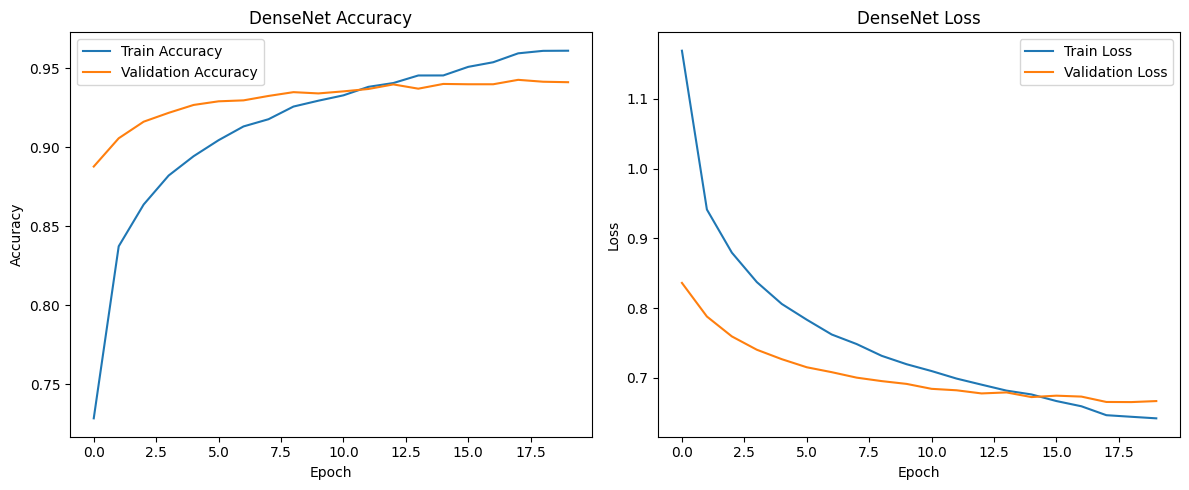

In [26]:
import matplotlib.pylab as plt

# =========================================================
# PLOT DENSENET TRAINING RESULTS
# =========================================================

plt.figure(figsize=(12, 5))

# =========================================================
# ACCURACY
# =========================================================

plt.subplot(1, 2, 1)

plt.plot(
    history_densenet.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_densenet.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('DenseNet Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

# =========================================================
# LOSS
# =========================================================

plt.subplot(1, 2, 2)

plt.plot(
    history_densenet.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_densenet.history['val_loss'],
    label='Validation Loss'
)

plt.title('DenseNet Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

# =========================================================
# SHOW
# =========================================================

plt.tight_layout()

plt.show()

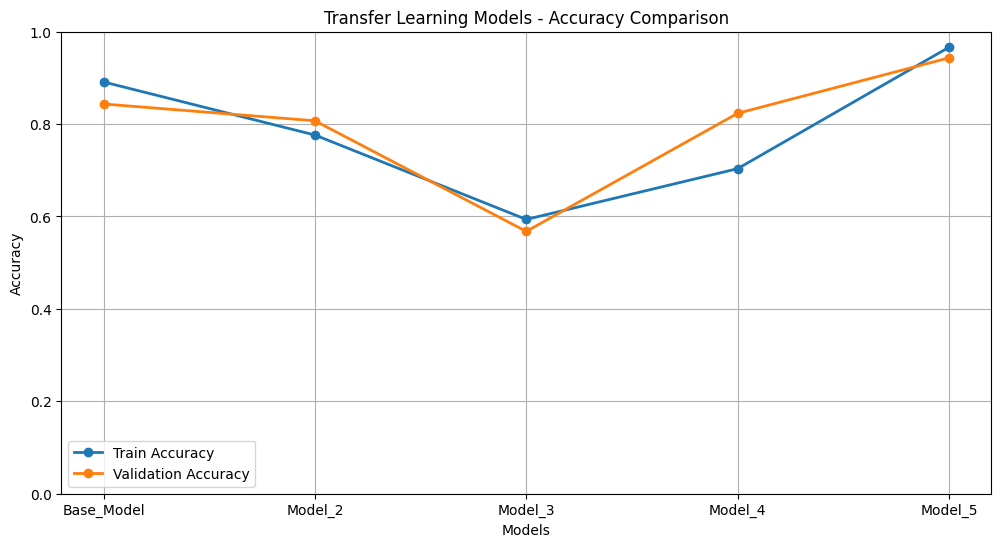

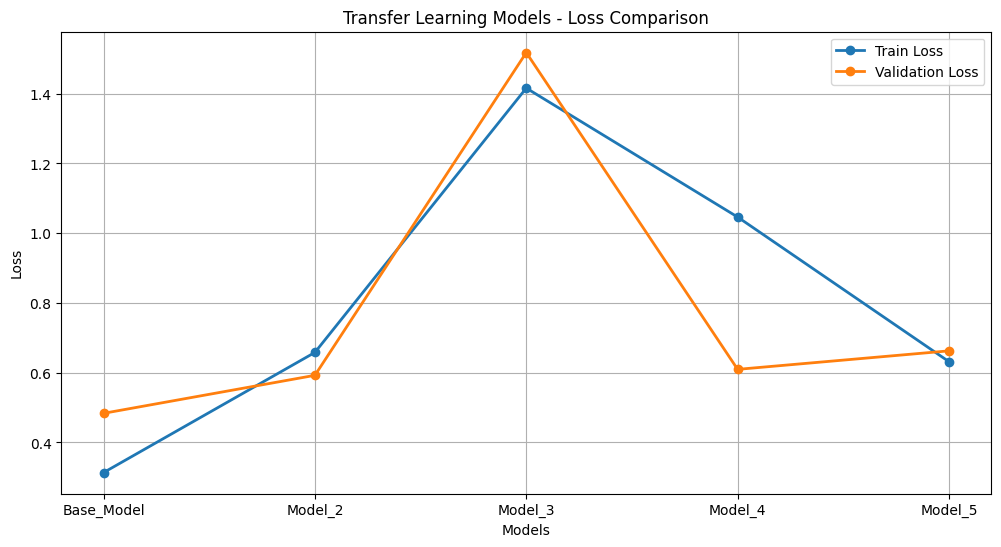

        Model  Train_Accuracy  Validation_Accuracy  Train_Loss  \
0  Base_Model          0.8910               0.8433      0.3131   
1     Model_2          0.7761               0.8069      0.6578   
2     Model_3          0.5934               0.5675      1.4160   
3     Model_4          0.7033               0.8231      1.0461   
4     Model_5          0.9661               0.9432      0.6312   

   Validation_Loss  
0           0.4831  
1           0.5921  
2           1.5179  
3           0.6092  
4           0.6623  


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe
results_transfer = pd.DataFrame({

    "Model": [
        "Base_Model",
        "Model_2",
        "Model_3",
        "Model_4",
        "Model_5"
    ],

    "Train_Accuracy": [
        0.8910,
        0.7761,
        0.5934,
        0.7033,
        0.9661
    ],

    "Validation_Accuracy": [
        0.8433,
        0.8069,
        0.5675,
        0.8231,
        0.9432
    ],

    "Train_Loss": [
        0.3131,
        0.6578,
        1.4160,
        1.0461,
        0.6312
    ],

    "Validation_Loss": [
        0.4831,
        0.5921,
        1.5179,
        0.6092,
        0.6623
    ]
})

# -----------------------------
# Plot 1: Accuracy Comparison
# -----------------------------

plt.figure(figsize=(12,6))

plt.plot(
    results_transfer["Model"],
    results_transfer["Train_Accuracy"],
    marker='o',
    linewidth=2,
    label='Train Accuracy'
)

plt.plot(
    results_transfer["Model"],
    results_transfer["Validation_Accuracy"],
    marker='o',
    linewidth=2,
    label='Validation Accuracy'
)

plt.title("Transfer Learning Models - Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.grid(True)
plt.legend()

plt.show()

# -----------------------------
# Plot 2: Loss Comparison
# -----------------------------

plt.figure(figsize=(12,6))

plt.plot(
    results_transfer["Model"],
    results_transfer["Train_Loss"],
    marker='o',
    linewidth=2,
    label='Train Loss'
)

plt.plot(
    results_transfer["Model"],
    results_transfer["Validation_Loss"],
    marker='o',
    linewidth=2,
    label='Validation Loss'
)

plt.title("Transfer Learning Models - Loss Comparison")
plt.xlabel("Models")
plt.ylabel("Loss")

plt.grid(True)
plt.legend()

plt.show()

# Optional: show dataframe
print(results_transfer)

In [13]:
# =========================================================
# LOAD TRAINED MODEL
# =========================================================

from tensorflow.keras.models import load_model

model_densenet = load_model(
    f"{project_path}/models/densenet_transfer_final.keras"
)

# =========================================================
# IMPORTS
# =========================================================

import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# =========================================================
# MAKE PREDICTIONS
# =========================================================

y_pred_probs = model_densenet.predict(X_test)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot encoded labels
y_true = np.argmax(y_test_cat, axis=1)

# =========================================================
# CIFAR-10 CLASS NAMES
# =========================================================

class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

# =========================================================
# CLASSIFICATION REPORT
# =========================================================

print("\nClassification Report:\n")

print(

    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )

)

# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nConfusion Matrix:\n")

print(cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 108ms/step

Classification Report:

              precision    recall  f1-score   support

    airplane       0.97      0.96      0.96      1000
  automobile       0.96      0.97      0.96      1000
        bird       0.95      0.93      0.94      1000
         cat       0.91      0.85      0.88      1000
        deer       0.94      0.94      0.94      1000
         dog       0.90      0.92      0.91      1000
        frog       0.94      0.98      0.96      1000
       horse       0.96      0.95      0.96      1000
        ship       0.97      0.97      0.97      1000
       truck       0.95      0.97      0.96      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000


Confusion Matrix:

[[956   5   4   2   1   0   1   2  16  13]
 [  2 972   0   0   0   0   0   1   3  22]
 [  6   0 930  13  20   7  18   2   4   0]
 [  2   3  19 853  16  